Model Performance:
MSE: 11.398528202006549
R2 Score: 0.8458454645398151


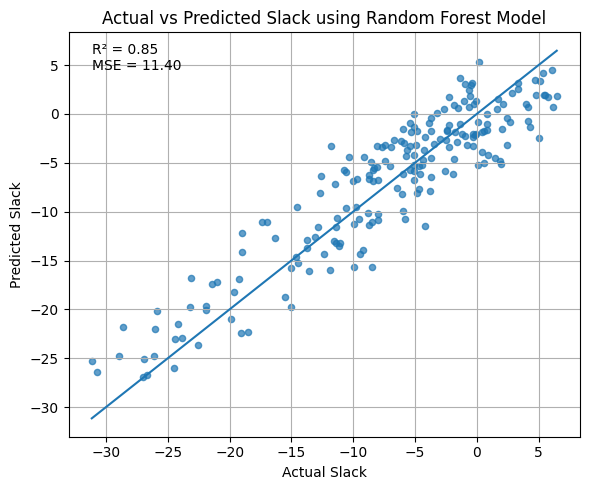

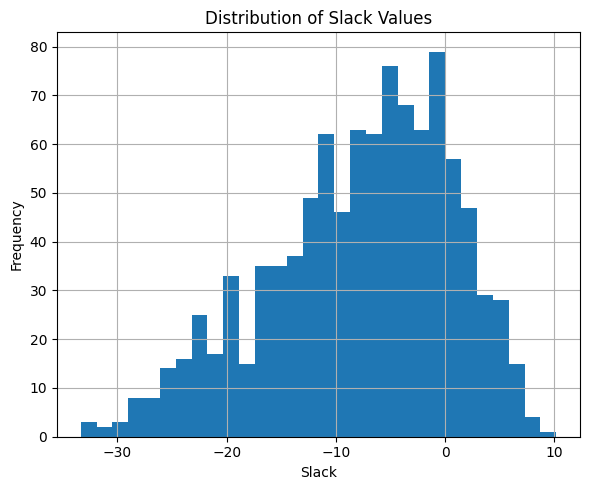

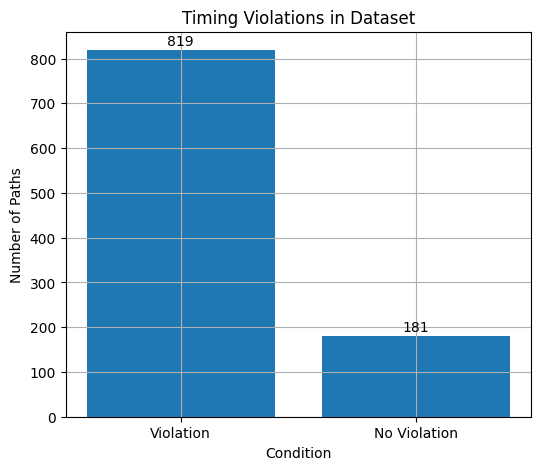

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# STEP 1: Generate Dataset
num_samples = 1000
data = []

for _ in range(num_samples):
    path_length = np.random.uniform(5, 20)
    fanout = np.random.randint(5, 30)
    load_cap = np.random.uniform(0.5, 3.0)
    gate_delay = np.random.uniform(0.5, 2.0)

    arrival_time = path_length * gate_delay + fanout * 0.1 + load_cap * 0.5
    required_time = np.random.uniform(5, 15)

    slack = required_time - arrival_time
    slack += np.random.normal(0, 1)

    data.append([path_length, fanout, load_cap, gate_delay, slack])

df = pd.DataFrame(data, columns=[
    "path_length", "fanout", "load_cap", "gate_delay", "slack"
])

# STEP 2: Create Violation Column
df["violation"] = df["slack"].apply(lambda x: 1 if x < 0 else 0)

# STEP 3: Prepare Data
X = df[["path_length", "fanout", "load_cap", "gate_delay"]]
y = df["slack"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 4: Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# STEP 5: Predict
pred = model.predict(X_test)

# STEP 6: Evaluate Model
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Model Performance:")
print("MSE:", mse)
print("R2 Score:", r2)

# ==============================
# 📊 PLOT 1: Actual vs Predicted
# ==============================
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred, s=20, alpha=0.7)

# Perfect prediction line
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Slack")
plt.ylabel("Predicted Slack")
plt.title("Actual vs Predicted Slack using Random Forest Model")
plt.grid(True)

# Add metrics on graph
plt.text(min_val, max_val - 2, f'R² = {r2:.2f}\nMSE = {mse:.2f}')

plt.tight_layout()
plt.show()

# ==============================
# 📊 PLOT 2: Slack Distribution
# ==============================
plt.figure(figsize=(6, 5))
plt.hist(df["slack"], bins=30)

plt.title("Distribution of Slack Values")
plt.xlabel("Slack")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================
# 📊 PLOT 3: Violation Count
# ==============================
counts = df["violation"].value_counts()

plt.figure(figsize=(6,5))
bars = plt.bar(['Violation', 'No Violation'], [counts[1], counts[0]])

plt.title("Timing Violations in Dataset")
plt.xlabel("Condition")
plt.ylabel("Number of Paths")
plt.grid(True)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center')

plt.show()